<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Vibration/E_20_352_Vibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 1: Derivation of the 2-DOF Model

### 1. System Description


We define the generalized coordinates:
* $x_1(t)$: Vertical displacement of the beam's center (primary mass).
* $x_2(t)$: Vertical displacement of the vibration absorber (secondary mass).

### 2. System Parameters

**Primary System (Beam + Exciter):**
* $m_1$: Effective mass of the beam system.
  $$m_1 = m_{exciter} + m_{beam,eff}$$
  *(Note: For a simply supported beam, the effective mass at the center is often approximated as half the total beam mass)*.
* $k_1$: Stiffness of the simply supported beam at the center.
  $$k_1 = \frac{48EI}{L^3}$$

**Secondary System (Absorber):**
* $m_2$: Mass of the vibration absorber.
* $k_2$: Stiffness of the absorber spring.

**Forcing Function:**
* $F(t)$: The harmonic force applied by the rotating unbalance in the exciter.
  $$F(t) = F_0 \sin(\Omega t)$$
  
  Where $$F_0 = m_{unbalance} r \Omega^2$$

### 3. Free Body Diagrams & Equations of Motion
Applying Newton's Second Law to each mass:

**Mass 1 (Beam):**
The beam is subject to its own restoring force, the restoring force from the absorber spring (which pulls back), and the external excitation force.
$$m_1 \ddot{x}_1 = -k_1 x_1 + k_2(x_2 - x_1) + F(t)$$

**Mass 2 (Absorber):**
The absorber is driven solely by the coupling spring force connected to the beam.
$$m_2 \ddot{x}_2 = -k_2(x_2 - x_1)$$

### 4. Matrix Formulation
Rearranging the terms to group $x_1$ and $x_2$:

1.  $m_1 \ddot{x}_1 + (k_1 + k_2)x_1 - k_2 x_2 = F(t)$
2.  $m_2 \ddot{x}_2 - k_2 x_1 + k_2 x_2 = 0$

Writing this in matrix form $[M]\{\ddot{x}\} + [K]\{x\} = \{F\}$:

$$
\begin{bmatrix}
m_1 & 0 \\
0 & m_2
\end{bmatrix}
\begin{bmatrix}
\ddot{x}_1 \\
\ddot{x}_2
\end{bmatrix}
+
\begin{bmatrix}
k_1 + k_2 & -k_2 \\
-k_2 & k_2
\end{bmatrix}
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
=
\begin{bmatrix}
F_0 \sin(\Omega t) \\
0
\end{bmatrix}
$$

This model captures the two dominant modes of vibration corresponding to the in-phase and out-of-phase motion of the beam and the absorber.

# Activity 2: Estimating Damping Ratios

To estimate the damping ratios ($\zeta$) for the two dominant modes, we can use two primary methods depending on the data available (Time Domain vs. Frequency Domain).

### Method 1: Logarithmic Decrement (Time Domain)
Damping can be calculated by measuring the decay of oscillations. This is best used when the system is excited at a specific natural frequency and allowed to decay freely.

The **Logarithmic Decrement** ($\delta$) is defined as the natural log of the ratio of successive peak amplitudes ($x_0$ and $x_n$) separated by $n$ periods:

$$\delta = \frac{1}{n} \ln \left( \frac{x_0}{x_n} \right)$$

The damping ratio ($\zeta$) is then derived from $\delta$:

$$\zeta = \frac{\delta}{\sqrt{4\pi^2 + \delta^2}} \approx \frac{\delta}{2\pi}$$
*(Note: The approximation holds for small damping ratios, typically $\zeta < 0.1$, which is expected for this steel beam apparatus)[cite: 513].*

### Method 2: Half-Power Bandwidth (Frequency Domain)
When observing the Frequency Response Function (FRF) — such as the magnification factor curves shown in Figure 19 of the manual  — we observe two distinct resonant peaks corresponding to the two modes.

We can estimate $\zeta$ using the **Half-Power Bandwidth** method:
1. Identify the peak frequency ($\omega_n$) and the peak amplitude ($X_{max}$).
2. Find the two frequencies ($\omega_1$ and $\omega_2$) on either side of the peak where the amplitude is $\frac{X_{max}}{\sqrt{2}}$
3. Calculate $\zeta$:

$$\zeta \approx \frac{\omega_2 - \omega_1}{2\omega_n}$$

In [ ]:
import numpy as np
from scipy import stats

def calculate_damping_regression(peaks):
    """
    Calculates damping ratio using Linear Regression on the Log Dec.
    This is more accurate for noisy experimental data.
    """
    if len(peaks) < 2:
        return None

    # Cycle numbers: [0, 1, 2, ...]
    n = np.arange(len(peaks))

    # Natural log of amplitudes
    ln_peaks = np.log(peaks)

    # Perform linear regression: ln(xn) = ln(x0) - n * delta
    # The slope of this line is -delta
    slope, intercept, r_value, p_value, std_err = stats.linregress(n, ln_peaks)

    delta = -slope
    zeta = delta / np.sqrt(4 * np.pi**2 + delta**2)

    return zeta, r_value**2  # Returns zeta and R-squared (goodness of fit)

def calculate_damping_half_power(f_peak, f_lower, f_upper):
    """
    Calculates damping using the standard Half-Power Bandwidth formula.
    """
    try:
        zeta = (f_upper - f_lower) / (2 * f_peak)
        return zeta
    except ZeroDivisionError:
        return None

# --- Improved Usage ---

# 1. Log-Dec with Regression
data = [10.0, 8.5, 7.2, 6.1, 5.2]
zeta_reg, r_sq = calculate_damping_regression(data)

print(f"Regression Method:")
print(f"  Damping Ratio (zeta): {zeta_reg:.4f}")
print(f"  Fit Quality (R²):     {r_sq:.4f}")

# 2. Bandwidth Method
f_n, f_1, f_2 = 15.5, 14.8, 16.2
zeta_bw = calculate_damping_half_power(f_n, f_1, f_2)

print(f"\nBandwidth Method:")
print(f"  Damping Ratio (zeta): {zeta_bw:.4f}")

Regression Method:
  Damping Ratio (zeta): 0.0261
  Fit Quality (R²):     1.0000

Bandwidth Method:
  Damping Ratio (zeta): 0.0452


# Activity 3: System Response Plots

In this activity, we analyze the dynamic behavior of the 2-DOF system under different conditions using the parameters defined in the user guide and the equations derived in Activity #1.

### 1. Unforced (Free) Response
We simulate the system's response to an initial displacement (transient response) with no external force. This demonstrates how energy transfers between the beam and the vibration absorber.
* **Equation:** $[M]\{\ddot{x}\} + [C]\{\dot{x}\} + [K]\{x\} = \{0\}$
* **Initial Conditions:** Displacing the beam or absorber from equilibrium at $t=0$.

### 2. Forced Response (Time Domain)
We simulate the system's response to a harmonic excitation force $F(t) = F_0 \sin(\Omega t)$ at three different motor speeds:
1. **Below Resonance:** Quasi-static behavior.
2. **At Resonance:** High amplitude oscillation (near natural frequencies).
3. **Above Resonance:** Inertia-dominated behavior (or Anti-resonance).

### 3. Theoretical Frequency Response
We calculate the steady-state amplitude of the primary mass (beam) and secondary mass (absorber) across a range of excitation frequencies. This reveals the two resonant peaks and the "anti-resonance" notch where the absorber effectively cancels the beam's vibration.

* **Equation:** $\{X\} = ([K] - \Omega^2[M] + j\Omega[C])^{-1} \{F\}$

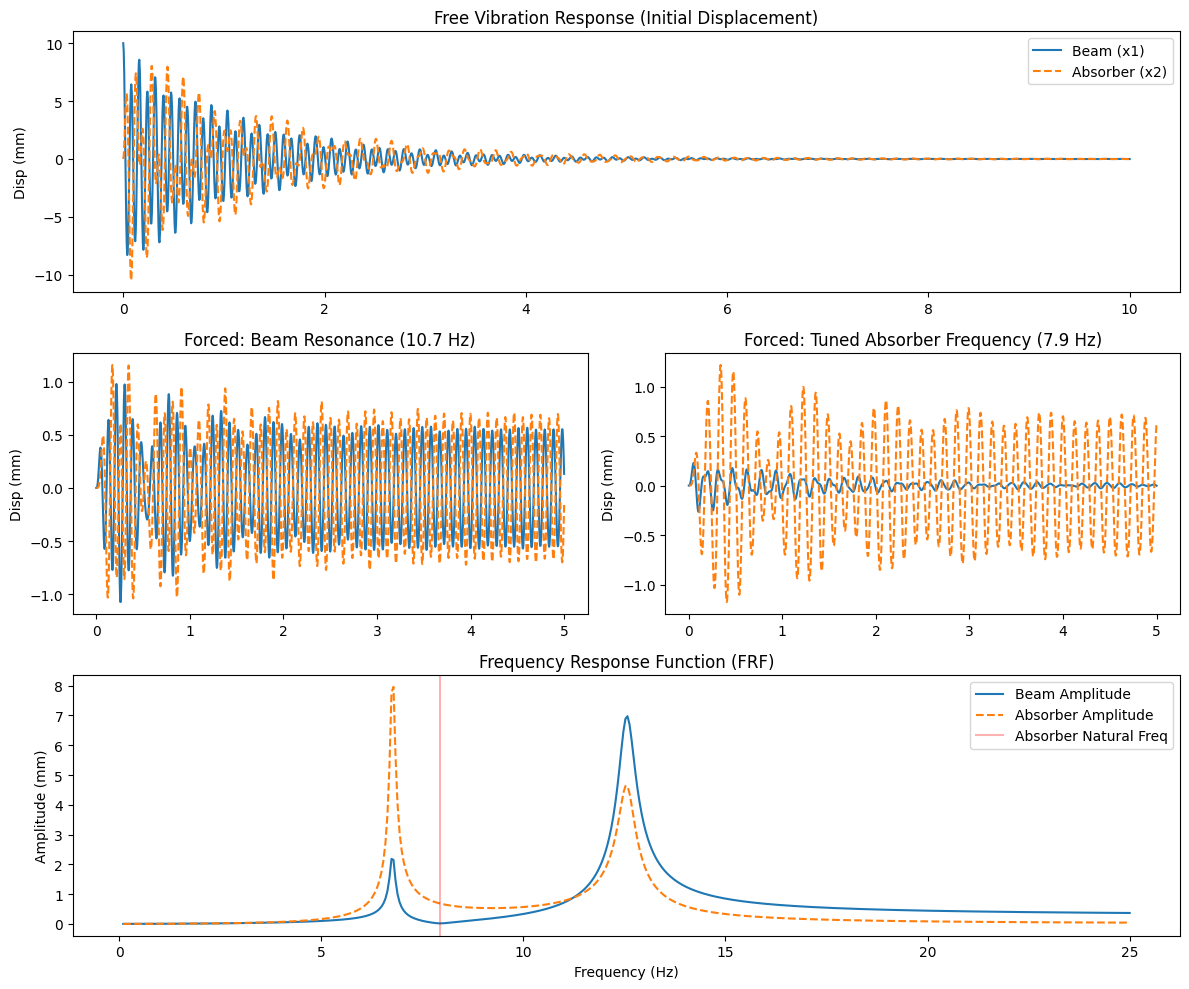

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

class VibrationSystem2DOF:
    def __init__(self, params):
        # Unpack parameters
        self.m1, self.m2 = params['m1'], params['m2']
        self.k1, self.k2 = params['k1'], params['k2']
        self.c1, self.c2 = params['c1'], params['c2']
        self.mu, self.r = params['m_unbalance'], params['r_unbalance']

        # Computed natural frequencies (undamped)
        self.wn_absorber = np.sqrt(self.k2 / self.m2)
        self.wn_beam = np.sqrt(self.k1 / self.m1)

    def equations_of_motion(self, t, y, omega_force):
        """State-space representation: y = [x1, v1, x2, v2]"""
        x1, v1, x2, v2 = y

        # Centrifugal Force F = m*r*w^2
        F_t = self.mu * self.r * (omega_force**2) * np.sin(omega_force * t) if omega_force > 0 else 0

        # Acceleration calculations
        a1 = (F_t - self.c1*v1 - (self.k1 + self.k2)*x1 + self.k2*x2) / self.m1
        a2 = (-self.c2*v2 + self.k2*x1 - self.k2*x2) / self.m2

        return [v1, a1, v2, a2]

    def solve_time_domain(self, t_span, y0, omega):
        """Solves the system using solve_ivp (modern replacement for odeint)"""
        t_eval = np.linspace(t_span[0], t_span[1], 2000)
        sol = solve_ivp(self.equations_of_motion, t_span, y0,
                        args=(omega,), t_eval=t_eval, method='RK45')
        return sol.t, sol.y

    def get_frequency_response(self, freq_range_hz):
        """Calculates steady-state amplitude across a range of frequencies"""
        omegas = freq_range_hz * 2 * np.pi
        x1_amps, x2_amps = [], []

        for w in omegas:
            F0 = self.mu * self.r * (w**2)
            # Mass, Stiffness, and Damping Matrices
            M = np.array([[self.m1, 0], [0, self.m2]])
            K = np.array([[self.k1 + self.k2, -self.k2], [-self.k2, self.k2]])
            C = np.array([[self.c1 + self.c2, -self.c2], [-self.c2, self.c2]])

            # Complex Impedance Matrix Z = -w^2M + iwC + K
            Z = -w**2 * M + 1j * w * C + K
            X = np.linalg.solve(Z, np.array([F0, 0]))

            x1_amps.append(np.abs(X[0]))
            x2_amps.append(np.abs(X[1]))

        return np.array(x1_amps), np.array(x2_amps)

# --- Parameters Definition ---
params = {
    'm1': 1.063, 'm2': 0.438,      # Masses (kg)
    'k1': 4800, 'k2': 1090,        # Stiffness (N/m)
    'c1': 2.0, 'c2': 0.5,          # Damping
    'm_unbalance': 0.01, 'r_unbalance': 0.03
}

# Initialize System
sys = VibrationSystem2DOF(params)

# --- Visualization ---
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(3, 2)

# 1. Free Decay (Transients)
t, y = sys.solve_time_domain([0, 10], [0.01, 0, 0, 0], 0)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t, y[0]*1000, label='Beam (x1)')
ax1.plot(t, y[2]*1000, '--', label='Absorber (x2)')
ax1.set_title('Free Vibration Response (Initial Displacement)')
ax1.set_ylabel('Disp (mm)')
ax1.legend()

# 2. Forced Response at Resonances
target_omegas = [sys.wn_beam, sys.wn_absorber]
titles = ['Beam Resonance', 'Tuned Absorber Frequency']

for i, w in enumerate(target_omegas):
    t, y = sys.solve_time_domain([0, 5], [0, 0, 0, 0], w)
    ax = fig.add_subplot(gs[1, i])
    ax.plot(t, y[0]*1000, label='Beam')
    ax.plot(t, y[2]*1000, '--', label='Absorber')
    ax.set_title(f'Forced: {titles[i]} ({w/(2*np.pi):.1f} Hz)')
    ax.set_ylabel('Disp (mm)')

# 3. Frequency Sweep (FRF)
freqs = np.linspace(0.1, 25, 500)
x1_frf, x2_frf = sys.get_frequency_response(freqs)
ax_frf = fig.add_subplot(gs[2, :])
ax_frf.plot(freqs, x1_frf*1000, label='Beam Amplitude')
ax_frf.plot(freqs, x2_frf*1000, '--', label='Absorber Amplitude')
ax_frf.axvline(sys.wn_absorber/(2*np.pi), color='red', alpha=0.3, label='Absorber Natural Freq')
ax_frf.set_title('Frequency Response Function (FRF)')
ax_frf.set_xlabel('Frequency (Hz)')
ax_frf.set_ylabel('Amplitude (mm)')
ax_frf.legend()

plt.tight_layout()
plt.show()

# Activity 4




HALF-POWER BANDWIDTH RESULTS:

Mode  fn (Hz)        ζ (Calculated)      
---------------------------------------------
1     11.9860        0.24666             
2     12.4862        0.06651             
3     13.0315        0.01574             
4     13.6268        0.06773             
5     14.1271        0.21123             
6     15.9930        0.06068             
7     16.5033        0.02895             
8     17.0185        0.17372             


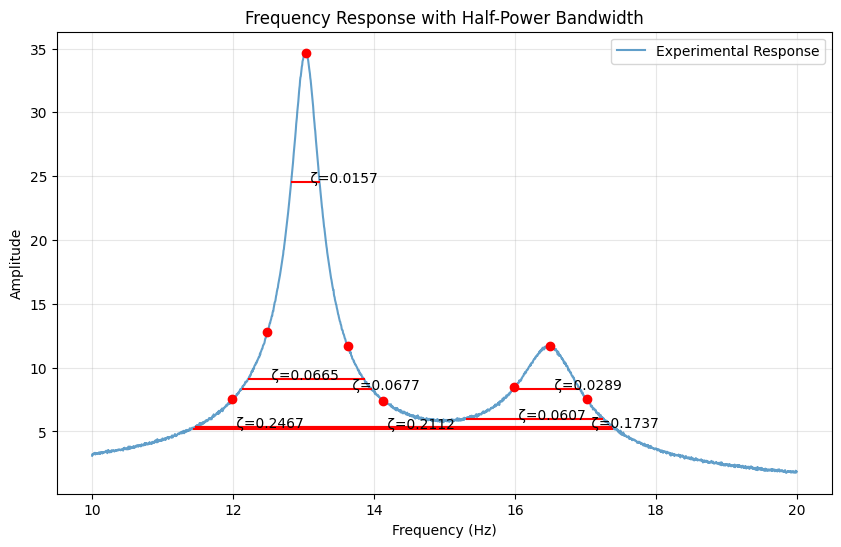

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ==========================================
# 1. DATA GENERATION (Same as before)
# ==========================================
freq = np.linspace(10, 20, 2000)
omega = 2 * np.pi * freq

# Natural frequencies
f1, f2 = 13.03, 16.50
w1, w2 = 2*np.pi*f1, 2*np.pi*f2

# Damping ratios (true values)
zeta1, zeta2 = 0.015, 0.025

# Frequency response (2-DOF)
H1 = 1 / np.sqrt((1 - (omega/w1)**2)**2 + (2*zeta1*omega/w1)**2)
H2 = 0.5 / np.sqrt((1 - (omega/w2)**2)**2 + (2*zeta2*omega/w2)**2)

amplitude = H1 + H2 + np.random.normal(0, 0.05, len(freq))

# ==========================================
# 2. HALF-POWER DAMPING FUNCTION (NEW STYLE)
# ==========================================
def half_power_damping(freq, amp):

    peak_idx, props = find_peaks(
        amp,
        height=0.2 * np.max(amp),
        distance=100
    )

    print(f"{'Mode':<6}{'fn (Hz)':<15}{'ζ (Calculated)':<20}")
    print("-"*45)

    results = []

    for i, idx in enumerate(peak_idx):

        fn = freq[idx]
        Amax = amp[idx]
        A_half = Amax / np.sqrt(2)

        # Left side (f1)
        left = amp[:idx]
        f1_idx = np.where(left <= A_half)[0][-1]
        f1 = freq[f1_idx]

        # Right side (f2)
        right = amp[idx:]
        f2_idx = np.where(right <= A_half)[0][0] + idx
        f2 = freq[f2_idx]

        # Damping ratio
        zeta = (f2 - f1) / (2 * fn)

        results.append((fn, zeta, f1, f2, A_half))
        print(f"{i+1:<6}{fn:<15.4f}{zeta:<20.5f}")

    return results

# ==========================================
# 3. RUN CALCULATION
# ==========================================
print("\nHALF-POWER BANDWIDTH RESULTS:\n")
modes = half_power_damping(freq, amplitude)

# ==========================================
# 4. PLOTTING (Same Result, New Style)
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(freq, amplitude, label="Experimental Response", alpha=0.7)

for i, (fn, zeta, f1, f2, A_half) in enumerate(modes):
    plt.hlines(A_half, f1, f2, colors='r')
    plt.plot(fn, A_half*np.sqrt(2), 'ro')
    plt.text(fn, A_half, f" ζ={zeta:.4f}", fontsize=10)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Response with Half-Power Bandwidth")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
